<a href="https://colab.research.google.com/github/Marcelo-Silvestre/MVP_Machine_Learning_Analytics_PUCRIO_40530010056_20260_01/blob/main/Notebooks/MVP_Machine_Learning_Previsao_Ocorrencias_Criminais_BR_UF_Final-mod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

## Previsão de vítimas por tipo criminal no Brasil e por Unidade Federativa em 2026

**Aluno:** Marcelo Alexandre Machado Silvestre

**Matrícula:** 4052025001857

**Data:** 30/06/2026

**Dataset:** Base de Dados e Notas Metodológicas dos Gestores Estaduais - Sinesp VDE 2015 a 2026.

- **Disponível em:** https://www.gov.br/mj/pt-br/assuntos/sua-seguranca/seguranca-publica/estatistica/dados-nacionais-1/base-de-dados-e-notas-metodologicas-dos-gestores-estaduais-sinesp-vde-2022-e-2023.

**Tipo de problema:** Regressão com características de séries temporais



# 1. Definição do problema

## 1.1 Descrição do problema

A segurança pública é um dos principais desafios enfrentados pelos gestores públicos brasileiros. O acompanhamento dos indicadores criminais permite compreender o comportamento da criminalidade ao longo do tempo, identificar tendências e subsidiar a formulação de políticas públicas voltadas à prevenção e ao combate dos diversos tipos de crimes.

Neste contexto, a disponibilidade de bases históricas de dados possibilita a aplicação de técnicas de Ciência de Dados e Machine Learning para identificar padrões temporais e realizar previsões sobre a evolução dos indicadores criminais. Essas previsões podem auxiliar órgãos de segurança pública no planejamento operacional, na alocação de recursos e na definição de estratégias de atuação.

O presente MVP utiliza dados do Sistema Nacional de Informações de Segurança Pública (SINESP), abrangendo o período de janeiro de 2020 a dezembro de 2025. Os dados foram agregados por tipo criminal, mês, ano e unidade federativa, permitindo construir séries históricas mensais em dois níveis de análise:

1. **Nível nacional:** previsão da quantidade mensal de vítimas por tipo criminal no Brasil.
2. **Nível estadual:** previsão da quantidade mensal de vítimas por tipo criminal e por UF.

O objetivo é desenvolver e avaliar modelos de Machine Learning capazes de prever a quantidade mensal de vítimas para cada tipo criminal em 2026, tanto em nível nacional quanto por Unidade Federativa.

A solução proposta pode ser útil para gestores de segurança pública, analistas de inteligência, pesquisadores e órgãos governamentais interessados em compreender tendências criminais e apoiar processos de tomada de decisão baseados em evidências.

## 1.2 Objetivo do MVP

Construir e comparar diferentes algoritmos de regressão capazes de estimar a quantidade mensal de vítimas por tipo criminal em períodos futuros.

O MVP será desenvolvido em duas frentes:

- **Previsão nacional:** utilizando a base `df_vitimas_BR`.
- **Previsão por UF:** utilizando a base `df_vitimas_UF`.

Para isso, serão avaliados modelos baseline e algoritmos supervisionados de regressão, com métricas apropriadas para previsão numérica.

## 1.3 Tipo de problema

**Tipo escolhido:** Regressão com características de Séries Temporais / Forecasting.

**Justificativa:**  
O objetivo deste trabalho é prever a quantidade mensal de vítimas para cada tipo criminal em 2026. Como a variável alvo `total_vitima` é numérica e representa uma contagem, o problema é caracterizado como uma tarefa de regressão.

Além disso, os registros são mensais e seguem uma ordem cronológica entre 2020 e 2025. Por essa razão, o problema também possui características de forecasting, exigindo que a separação entre treino e teste preserve a sequência temporal dos dados.

## 1.4 Premissas, hipóteses e critérios de sucesso

### Hipóteses iniciais

**Hipótese 1:** Os dados históricos mensais de 2020 a 2025 contêm padrões temporais suficientes para apoiar a previsão da quantidade de vítimas por tipo criminal em 2026.

**Hipótese 2:** A variável `data_mes` contribui para capturar efeitos de sazonalidade, pois alguns tipos criminais podem apresentar variações ao longo dos meses do ano.

**Hipótese 3:** Modelos supervisionados de Machine Learning podem apresentar desempenho superior a um baseline temporal simples, baseado na repetição do valor observado no mesmo mês do ano anterior.

### Critérios de sucesso

**Métrica principal:** RMSE, por penalizar erros maiores e ser adequada para problemas de regressão.

**Métricas complementares:** MAE e R².

**Resultado mínimo esperado:** O MVP será considerado bem-sucedido se pelo menos um modelo supervisionado reduzir o RMSE em pelo menos 10% em relação ao baseline temporal.

**Restrição prática:** O notebook deve ser executável no Google Colab, com baixo custo computacional e sem dependência de arquivos locais.

# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção reúne as bibliotecas utilizadas e define configurações mínimas para reprodutibilidade dos experimentos.

In [ ]:
# Bibliotecas gerais
import sys
import time
import random
import warnings

# Manipulação e cálculo numérico
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt

# Pré-processamento e pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Modelos de regressão
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Seleção e validação de modelos
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

SEMENTE = 42
np.random.seed(SEMENTE)
random.seed(SEMENTE)

print("Versão do Python:", sys.version.split()[0])
print("Semente definida:", SEMENTE)

Versão do Python: 3.12.13
Semente definida: 42


## 2.1 Dependências adicionais

Não foram instaladas bibliotecas adicionais. Utilizadas apenas bibliotecas usuais do ambiente Google Colab.

In [ ]:
# Não há instalação de dependências adicionais.
# O notebook utiliza pandas, numpy, matplotlib e scikit-learn.

## 2.2 Funções auxiliares

As funções abaixo foram criadas para evitar repetição de código, padronizar a avaliação dos modelos e facilitar a análise das hipóteses.

In [ ]:
def medir_desempenho_regressao(valores_reais, valores_previstos):
    """
    Calcula métricas de regressão para comparar valores reais e previstos.
    """
    erro_quadratico_medio = mean_squared_error(valores_reais, valores_previstos)

    return {
        "MAE": mean_absolute_error(valores_reais, valores_previstos),
        "RMSE": np.sqrt(erro_quadratico_medio),
        "R2": r2_score(valores_reais, valores_previstos)
    }


def montar_quadro_comparativo(dic_resultados):
    """
    Organiza os resultados dos modelos em uma tabela ordenada pelo RMSE.
    """
    return pd.DataFrame(dic_resultados).T.sort_values("RMSE")


def calcular_reducao_percentual(valor_referencia, valor_comparado):
    """
    Calcula a redução percentual de erro em relação a uma referência.
    """
    return ((valor_referencia - valor_comparado) / valor_referencia) * 100


def plotar_barras_ordenadas(serie, titulo, xlabel, ylabel, top_n=None):
    """
    Plota uma série ordenada em barras horizontais.
    """
    dados_plot = serie.copy()
    if top_n is not None:
        dados_plot = dados_plot.head(top_n)

    plt.figure(figsize=(10, 6))
    dados_plot.sort_values().plot(kind="barh")
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset utilizado neste MVP foi obtido a partir das bases públicas disponibilizadas pelo **Sistema Nacional de Informações de Segurança Pública (SINESP)**, mantido pelo Ministério da Justiça e Segurança Pública do Brasil.

**Nome do dataset:** Base de Dados e Notas Metodológicas dos Gestores Estaduais - Sinesp VDE 2015 a 2026.

**Fonte:** https://www.gov.br/mj/pt-br/assuntos/sua-seguranca/seguranca-publica/estatistica/dados-nacionais-1/base-de-dados-e-notas-metodologicas-dos-gestores-estaduais-sinesp-vde-2022-e-2023

Foram utilizadas as bases anuais referentes ao período de **2020 a 2025**, contendo informações mensais de diferentes indicadores criminais reportados pelas unidades federativas brasileiras.

O dataset foi escolhido por reunir dados oficiais de segurança pública de abrangência nacional, permitindo analisar a evolução temporal de diferentes tipos criminais e construir modelos preditivos para estimar a quantidade mensal de vítimas em períodos futuros.

Como restrição metodológica, foram considerados apenas registros com `total_vitima > 0`, pois o foco do MVP é prever a quantidade de vítimas. Eventos relacionados a quantidades de drogas, armas ou outros totais que não representem vítimas não fazem parte da variável alvo deste estudo.

Sob a perspectiva ética e de privacidade, não foram identificadas restrições relevantes, pois os dados são públicos, agregados e não contêm informações pessoais identificáveis.

Os arquivos são carregados diretamente no notebook por meio de URLs públicas no GitHub, sem upload manual e sem dependência de arquivos locais.

## 3.2 Carga dos dados

As bases anuais carregadas diretamente dos arquivos CSV hospedados no GitHub.

In [ ]:
# URLs públicas dos arquivos CSV no GitHub.

url_base_2020 = "https://raw.githubusercontent.com/Marcelo-Silvestre/MVP_Machine_Learning_Analytics_PUCRIO_40530010056_20260_01/main/arquivos/BancoVDE_2020.csv"
url_base_2021 = "https://raw.githubusercontent.com/Marcelo-Silvestre/MVP_Machine_Learning_Analytics_PUCRIO_40530010056_20260_01/main/arquivos/BancoVDE_2021.csv"
url_base_2022 = "https://raw.githubusercontent.com/Marcelo-Silvestre/MVP_Machine_Learning_Analytics_PUCRIO_40530010056_20260_01/main/arquivos/BancoVDE_2022.csv"
url_base_2023 = "https://raw.githubusercontent.com/Marcelo-Silvestre/MVP_Machine_Learning_Analytics_PUCRIO_40530010056_20260_01/main/arquivos/BancoVDE_2023.csv"
url_base_2024 = "https://raw.githubusercontent.com/Marcelo-Silvestre/MVP_Machine_Learning_Analytics_PUCRIO_40530010056_20260_01/main/arquivos/BancoVDE_2024.csv"
url_base_2025 = "https://raw.githubusercontent.com/Marcelo-Silvestre/MVP_Machine_Learning_Analytics_PUCRIO_40530010056_20260_01/main/arquivos/BancoVDE_2025.csv"

# Leitura individual das bases anuais.
base_2020 = pd.read_csv(url_base_2020, sep=";", low_memory=False)
base_2021 = pd.read_csv(url_base_2021, sep=";", low_memory=False)
base_2022 = pd.read_csv(url_base_2022, sep=";", low_memory=False)
base_2023 = pd.read_csv(url_base_2023, sep=";", low_memory=False)
base_2024 = pd.read_csv(url_base_2024, sep=";", low_memory=False)
base_2025 = pd.read_csv(url_base_2025, sep=";", low_memory=False)

# Consolidação das bases anuais em um único dataframe.
dados_brutos = pd.concat(
    [base_2020, base_2021, base_2022, base_2023, base_2024, base_2025],
    ignore_index=True
)

dados_brutos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4654995 entries, 0 to 4654994
Data columns (total 14 columns):
 #   Column           Dtype  
---  ------           -----  
 0   uf               object 
 1   municipio        object 
 2   evento           object 
 3   data_referencia  object 
 4   agente           object 
 5   arma             object 
 6   faixa_etaria     object 
 7   feminino         float64
 8   masculino        float64
 9   nao_informado    float64
 10  total_vitima     float64
 11  total            float64
 12  total_peso       float64
 13  abrangencia      object 
dtypes: float64(6), object(8)
memory usage: 497.2+ MB


## 3.3 Construção da base com vítimas

Nesta etapa, a base original é filtrada para manter apenas registros com `total_vitima > 0`. Em seguida, são criadas as variáveis `data_mes` e `data_ano`.

In [ ]:
# Cópia da base original para iniciar a preparação.
dados_vitimas = dados_brutos.copy()

# Conversão da coluna de data para datetime.
dados_vitimas["data_referencia"] = pd.to_datetime(
    dados_vitimas["data_referencia"],
    dayfirst=True,
    errors="coerce"
)

# Seleção apenas dos registros com vítimas e das colunas necessárias.
dados_vitimas = dados_vitimas.loc[
    dados_vitimas["total_vitima"] > 0,
    [
        "uf",
        "evento",
        "data_referencia",
        "feminino",
        "masculino",
        "nao_informado",
        "total_vitima"
    ]
].copy()

# Criação de mês e ano logo após a coluna de data.
posicao_data = dados_vitimas.columns.get_loc("data_referencia")

dados_vitimas.insert(
    posicao_data + 1,
    "data_mes",
    dados_vitimas["data_referencia"].dt.month
)

dados_vitimas.insert(
    posicao_data + 2,
    "data_ano",
    dados_vitimas["data_referencia"].dt.year
)

# Agregação por UF, tipo criminal e período mensal.
dados_vitimas = (
    dados_vitimas
    .groupby(
        ["uf", "evento", "data_referencia", "data_mes", "data_ano"],
        as_index=False
    )
    .agg({
        "feminino": "sum",
        "masculino": "sum",
        "nao_informado": "sum",
        "total_vitima": "sum"
    })
    .sort_values(["uf", "evento", "data_ano", "data_mes"])
)

dados_vitimas.head()

,uf,evento,data_referencia,data_mes,data_ano,feminino,masculino,nao_informado,total_vitima
0,AC,Estupro,2020-01-01,1,2020,12.0,1.0,1.0,14.0
1,AC,Estupro,2020-02-01,2,2020,12.0,0.0,0.0,12.0
2,AC,Estupro,2020-03-01,3,2020,5.0,0.0,0.0,5.0
3,AC,Estupro,2020-04-01,4,2020,6.0,0.0,0.0,6.0
4,AC,Estupro,2020-05-01,5,2020,2.0,1.0,0.0,3.0


## 3.4 Base nacional para modelagem — `df_vitimas_BR`

A base nacional consolida o total de vítimas por tipo criminal, mês e ano, somando todos os estados.

In [ ]:
# Base nacional agregada por evento, mês e ano.
df_vitimas_BR = (
    dados_vitimas
    .groupby(["evento", "data_mes", "data_ano"], as_index=False)["total_vitima"]
    .sum()
    .sort_values(["evento", "data_ano", "data_mes"])
)

# Índice temporal nacional: janeiro de 2020 = 1, dezembro de 2025 = 72.
df_vitimas_BR["num_evento_BR"] = (
    (df_vitimas_BR["data_ano"] - 2020) * 12
    + df_vitimas_BR["data_mes"]
)

# Organização das colunas.
df_vitimas_BR = df_vitimas_BR[
    ["evento", "data_mes", "data_ano", "num_evento_BR", "total_vitima"]
]

df_vitimas_BR.head()

,evento,data_mes,data_ano,num_evento_BR,total_vitima
0,Estupro,1,2020,1,2217.0
6,Estupro,2,2020,2,2052.0
12,Estupro,3,2020,3,1766.0
18,Estupro,4,2020,4,1423.0
24,Estupro,5,2020,5,1461.0


## 3.5 Base por Unidade Federativa para modelagem — `df_vitimas_UF`

A base por UF mantém a granularidade estadual, permitindo prever a quantidade mensal de vítimas por tipo criminal em cada unidade federativa.

In [ ]:
# Base por UF agregada por estado, evento, mês e ano.
df_vitimas_UF = (
    dados_vitimas
    .groupby(["uf", "evento", "data_mes", "data_ano"], as_index=False)["total_vitima"]
    .sum()
    .sort_values(["uf", "evento", "data_ano", "data_mes"])
)

# Índice temporal por UF e tipo criminal.
# A contagem reinicia para cada combinação de UF e evento.
df_vitimas_UF["num_evento_UF"] = (
    df_vitimas_UF
    .groupby(["uf", "evento"])
    .cumcount()
    + 1
)

# Organização das colunas.
df_vitimas_UF = df_vitimas_UF[
    ["uf", "evento", "data_mes", "data_ano", "num_evento_UF", "total_vitima"]
]

df_vitimas_UF.head()

,uf,evento,data_mes,data_ano,num_evento_UF,total_vitima
0,AC,Estupro,1,2020,1,14.0
6,AC,Estupro,2,2020,2,12.0
12,AC,Estupro,3,2020,3,5.0
18,AC,Estupro,4,2020,4,6.0
24,AC,Estupro,5,2020,5,3.0


## 3.6 Visão geral dos datasets

In [ ]:
print("Base nacional — df_vitimas_BR:", df_vitimas_BR.shape)
print("Base por UF — df_vitimas_UF:", df_vitimas_UF.shape)

print("Tipos da base nacional:")
display(df_vitimas_BR.dtypes.to_frame("tipo"))

print("Tipos da base por UF:")
display(df_vitimas_UF.dtypes.to_frame("tipo"))

print("Ausentes na base nacional:")
display(df_vitimas_BR.isna().sum().to_frame("ausentes"))

print("Ausentes na base por UF:")
display(df_vitimas_UF.isna().sum().to_frame("ausentes"))

print("Duplicatas na base nacional:", df_vitimas_BR.duplicated().sum())
print("Duplicatas na base por UF:", df_vitimas_UF.duplicated().sum())

Base nacional — df_vitimas_BR: (1224, 5)
Base por UF — df_vitimas_UF: (27704, 6)
Tipos da base nacional:


,tipo
evento,object
data_mes,int32
data_ano,int32
num_evento_BR,int32
total_vitima,float64


Tipos da base por UF:


,tipo
uf,object
evento,object
data_mes,int32
data_ano,int32
num_evento_UF,int64
total_vitima,float64


Ausentes na base nacional:


,ausentes
evento,0
data_mes,0
data_ano,0
num_evento_BR,0
total_vitima,0


Ausentes na base por UF:


,ausentes
uf,0
evento,0
data_mes,0
data_ano,0
num_evento_UF,0
total_vitima,0


Duplicatas na base nacional: 0
Duplicatas na base por UF: 0


## 3.7 Dicionário de dados

### Base nacional — `df_vitimas_BR`

| Coluna | Tipo | Descrição | Será usada no modelo? |
|---|---|---|---|
| `evento` | Categórica | Tipo criminal registrado | Sim |
| `data_mes` | Numérica | Mês de referência | Sim |
| `data_ano` | Numérica | Ano de referência | Sim |
| `num_evento_BR` | Numérica | Índice temporal nacional mensal | Sim |
| `total_vitima` | Numérica | Quantidade mensal de vítimas | Alvo |

### Base por UF — `df_vitimas_UF`

| Coluna | Tipo | Descrição | Será usada no modelo? |
|---|---|---|---|
| `uf` | Categórica | Unidade Federativa | Sim |
| `evento` | Categórica | Tipo criminal registrado | Sim |
| `data_mes` | Numérica | Mês de referência | Sim |
| `data_ano` | Numérica | Ano de referência | Sim |
| `num_evento_UF` | Numérica | Índice temporal mensal por UF e evento | Sim |
| `total_vitima` | Numérica | Quantidade mensal de vítimas | Alvo |

# 4. Análise exploratória dos dados

A análise exploratória foi dividida em duas partes: análise nacional e análise por UF.

## 4.1 Estatísticas descritivas — base nacional

In [ ]:
df_vitimas_BR.describe()

,data_mes,data_ano,num_evento_BR,total_vitima
count,1224.000000,1224.000000,1224.0000,1224.000000
mean,6.500000,2022.500000,36.5000,1704.252451
std,3.453464,1.708523,20.7911,1889.987271
min,1.000000,2020.000000,1.0000,5.000000
25%,3.750000,2021.000000,18.7500,118.750000
50%,6.500000,2022.500000,36.5000,1013.000000
75%,9.250000,2024.000000,54.2500,2943.250000
max,12.000000,2025.000000,72.0000,7578.000000


## 4.2 Estatísticas descritivas — base por UF

In [ ]:
df_vitimas_UF.describe()

## 4.3 Distribuição da variável alvo na base nacional

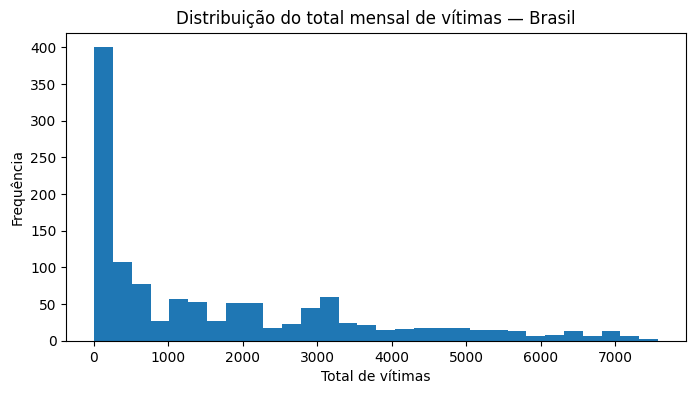

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df_vitimas_BR["total_vitima"], bins=30)
plt.title("Distribuição do total mensal de vítimas — Brasil")
plt.xlabel("Total de vítimas")
plt.ylabel("Frequência")
plt.show()

## 4.4 Distribuição da variável alvo na base por UF

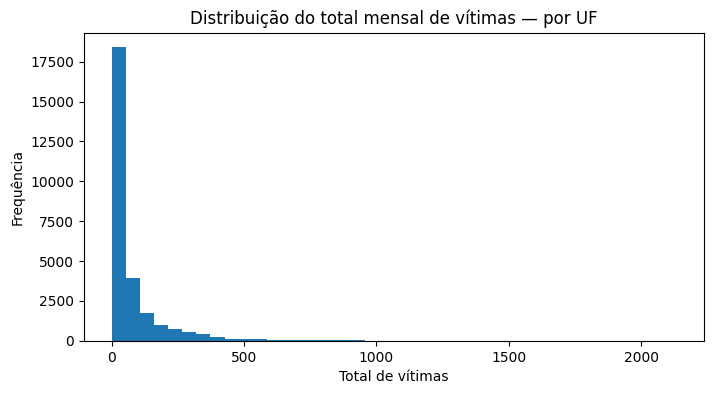

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df_vitimas_UF["total_vitima"], bins=40)
plt.title("Distribuição do total mensal de vítimas — por UF")
plt.xlabel("Total de vítimas")
plt.ylabel("Frequência")
plt.show()

## 4.5 Boxplot da variável alvo — Brasil

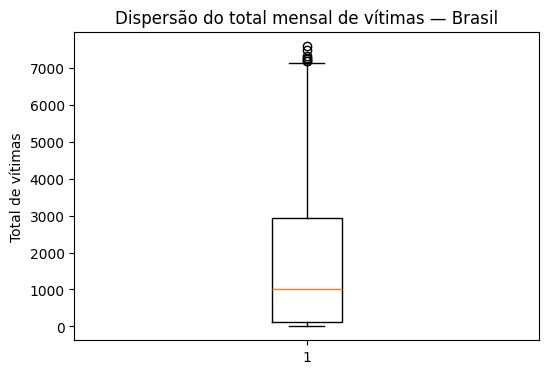

In [ ]:
plt.figure(figsize=(6, 4))
plt.boxplot(df_vitimas_BR["total_vitima"])
plt.title("Dispersão do total mensal de vítimas — Brasil")
plt.ylabel("Total de vítimas")
plt.show()

## 4.6 Top 10 tipos criminais por volume de vítimas — Brasil

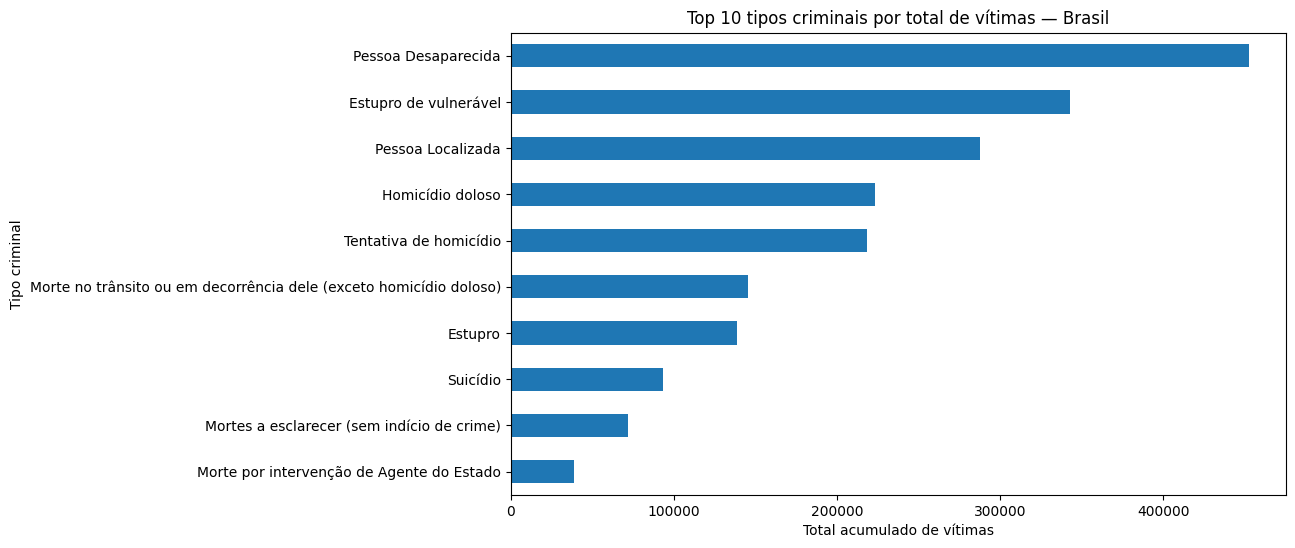

In [ ]:
vitimas_por_evento_br = (
    df_vitimas_BR
    .groupby("evento")["total_vitima"]
    .sum()
    .sort_values(ascending=False)
)

plotar_barras_ordenadas(
    vitimas_por_evento_br,
    "Top 10 tipos criminais por total de vítimas — Brasil",
    "Total acumulado de vítimas",
    "Tipo criminal",
    top_n=10
)

## 4.7 Participação percentual dos tipos criminais no total nacional

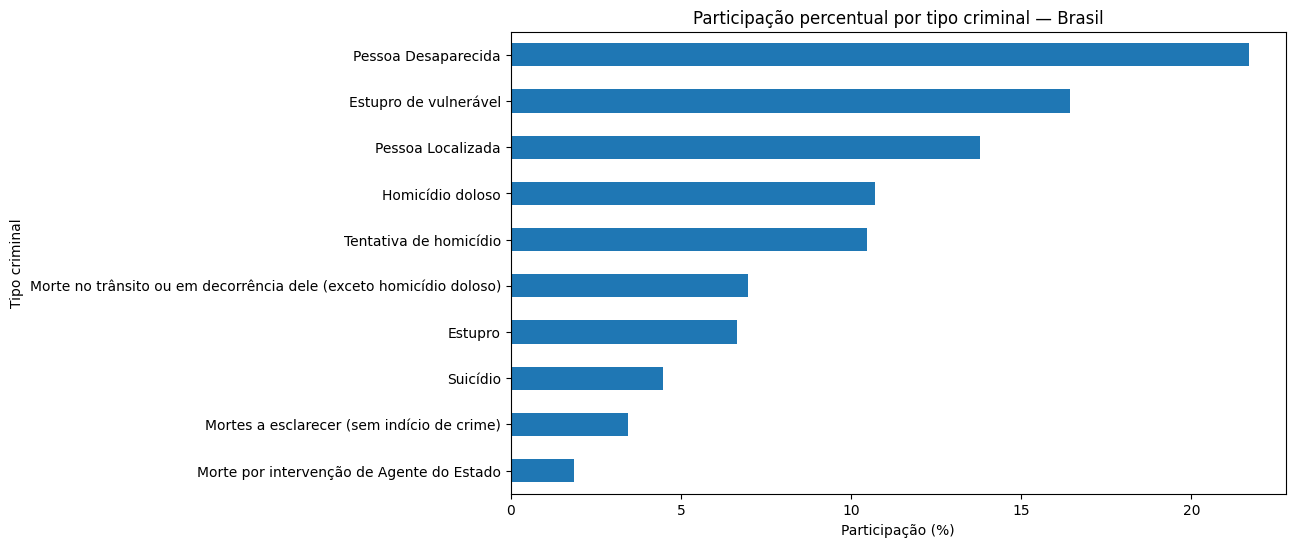

In [ ]:
participacao_eventos = (
    vitimas_por_evento_br
    / vitimas_por_evento_br.sum()
    * 100
).sort_values(ascending=False)

plotar_barras_ordenadas(
    participacao_eventos,
    "Participação percentual por tipo criminal — Brasil",
    "Participação (%)",
    "Tipo criminal",
    top_n=10
)

## 4.8 Evolução temporal agregada — Brasil

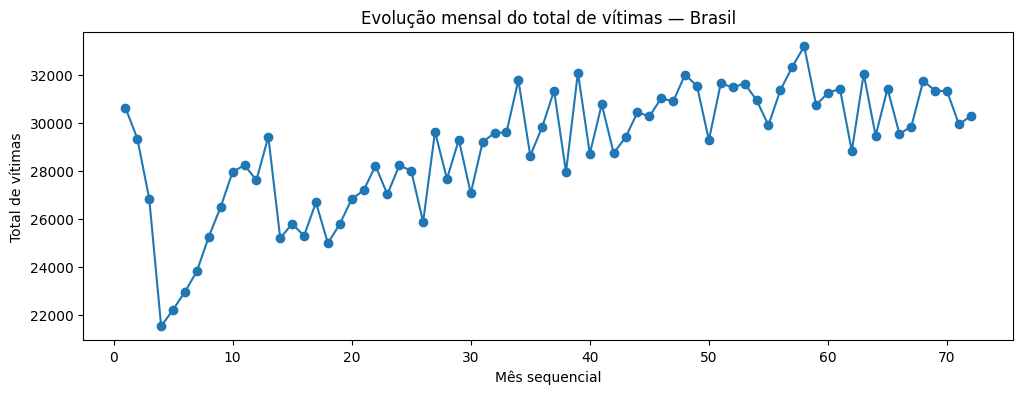

In [ ]:
serie_total_brasil = (
    df_vitimas_BR
    .groupby(["data_ano", "data_mes", "num_evento_BR"], as_index=False)["total_vitima"]
    .sum()
    .sort_values("num_evento_BR")
)

plt.figure(figsize=(12, 4))
plt.plot(
    serie_total_brasil["num_evento_BR"],
    serie_total_brasil["total_vitima"],
    marker="o"
)
plt.title("Evolução mensal do total de vítimas — Brasil")
plt.xlabel("Mês sequencial")
plt.ylabel("Total de vítimas")
plt.show()

## 4.9 Evolução anual agregada — Brasil

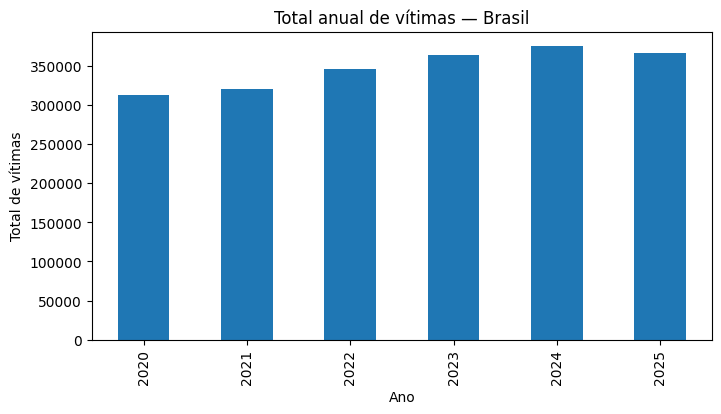

In [ ]:
vitimas_por_ano_br = (
    df_vitimas_BR
    .groupby("data_ano")["total_vitima"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(8, 4))
vitimas_por_ano_br.plot(kind="bar")
plt.title("Total anual de vítimas — Brasil")
plt.xlabel("Ano")
plt.ylabel("Total de vítimas")
plt.show()

## 4.10 Média mensal de vítimas — indício de sazonalidade

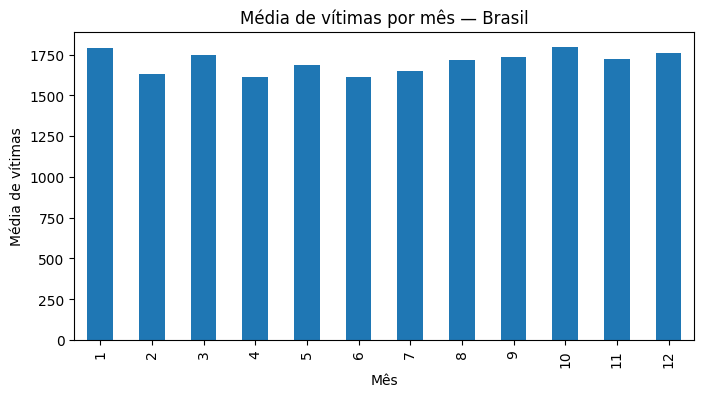

In [ ]:
media_mes_br = (
    df_vitimas_BR
    .groupby("data_mes")["total_vitima"]
    .mean()
)

plt.figure(figsize=(8, 4))
media_mes_br.plot(kind="bar")
plt.title("Média de vítimas por mês — Brasil")
plt.xlabel("Mês")
plt.ylabel("Média de vítimas")
plt.show()

## 4.11 Evolução temporal dos cinco tipos criminais com maior volume

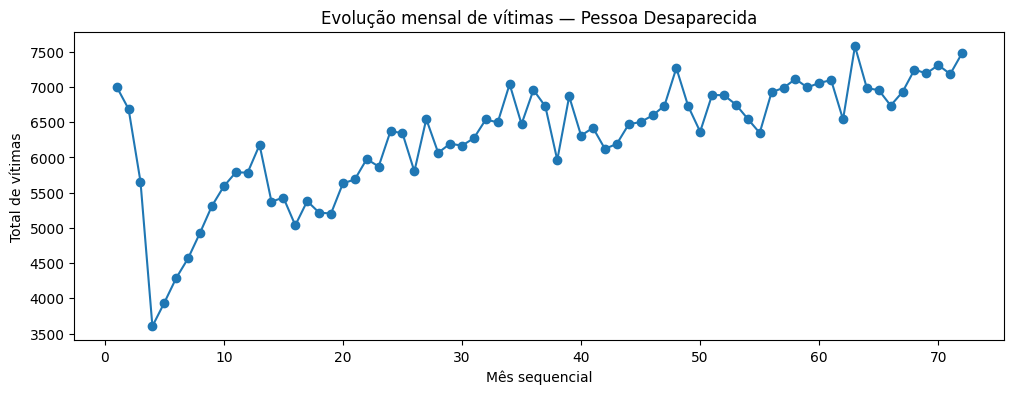

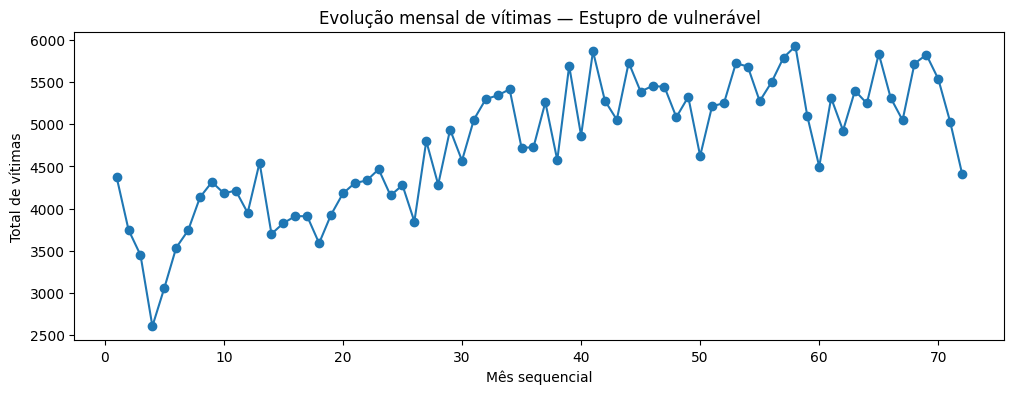

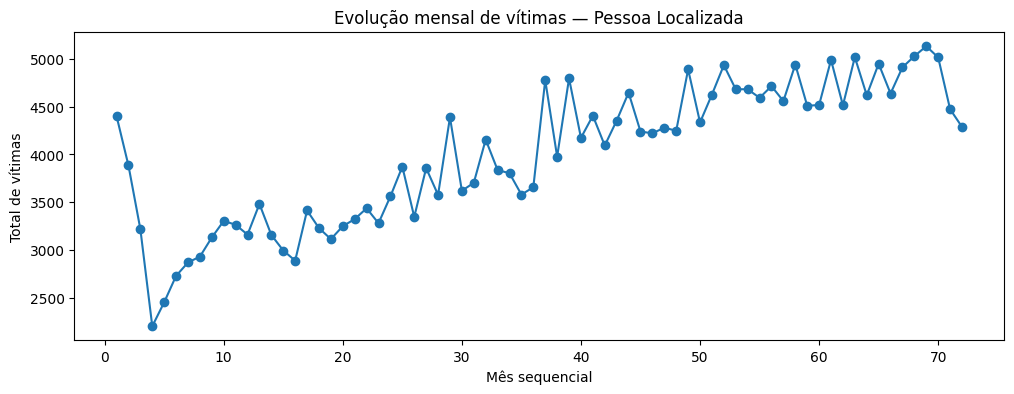

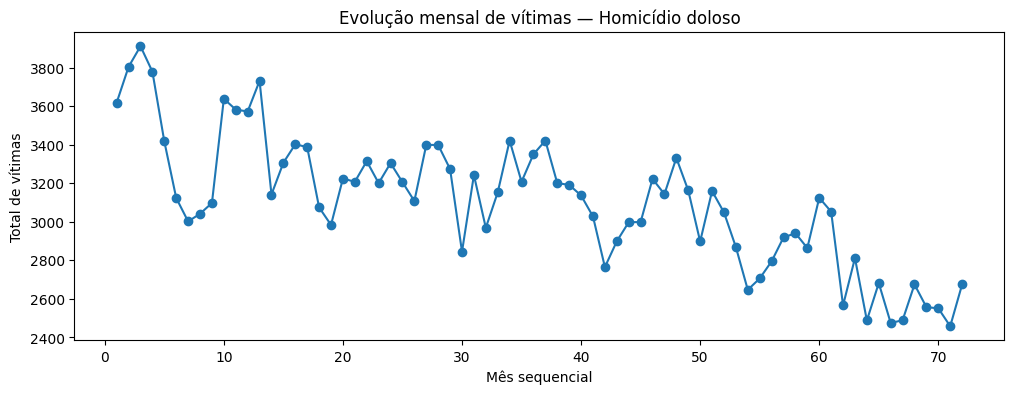

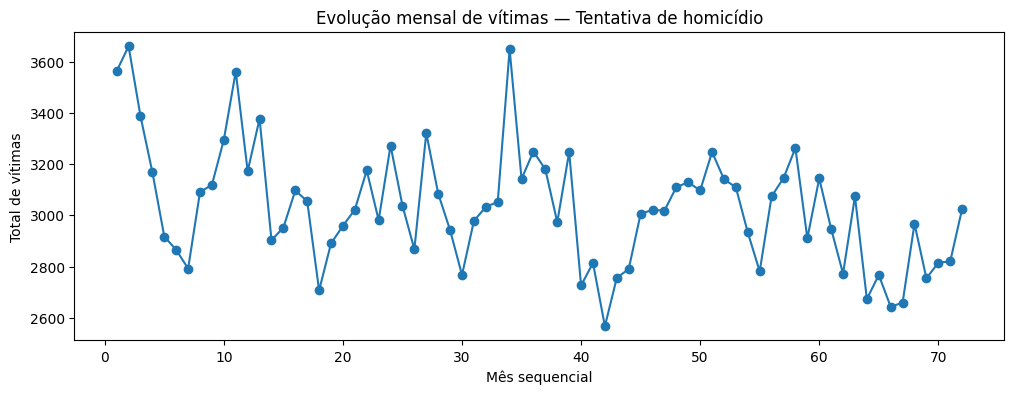

In [ ]:
top5_eventos = vitimas_por_evento_br.head(5).index.tolist()

for tipo in top5_eventos:
    dados_tipo = df_vitimas_BR[df_vitimas_BR["evento"] == tipo]

    plt.figure(figsize=(12, 4))
    plt.plot(
        dados_tipo["num_evento_BR"],
        dados_tipo["total_vitima"],
        marker="o"
    )
    plt.title(f"Evolução mensal de vítimas — {tipo}")
    plt.xlabel("Mês sequencial")
    plt.ylabel("Total de vítimas")
    plt.show()

## 4.12 Heatmap simples: média mensal por tipo criminal

O gráfico abaixo é usado para visualizar padrões mensais por tipo criminal.

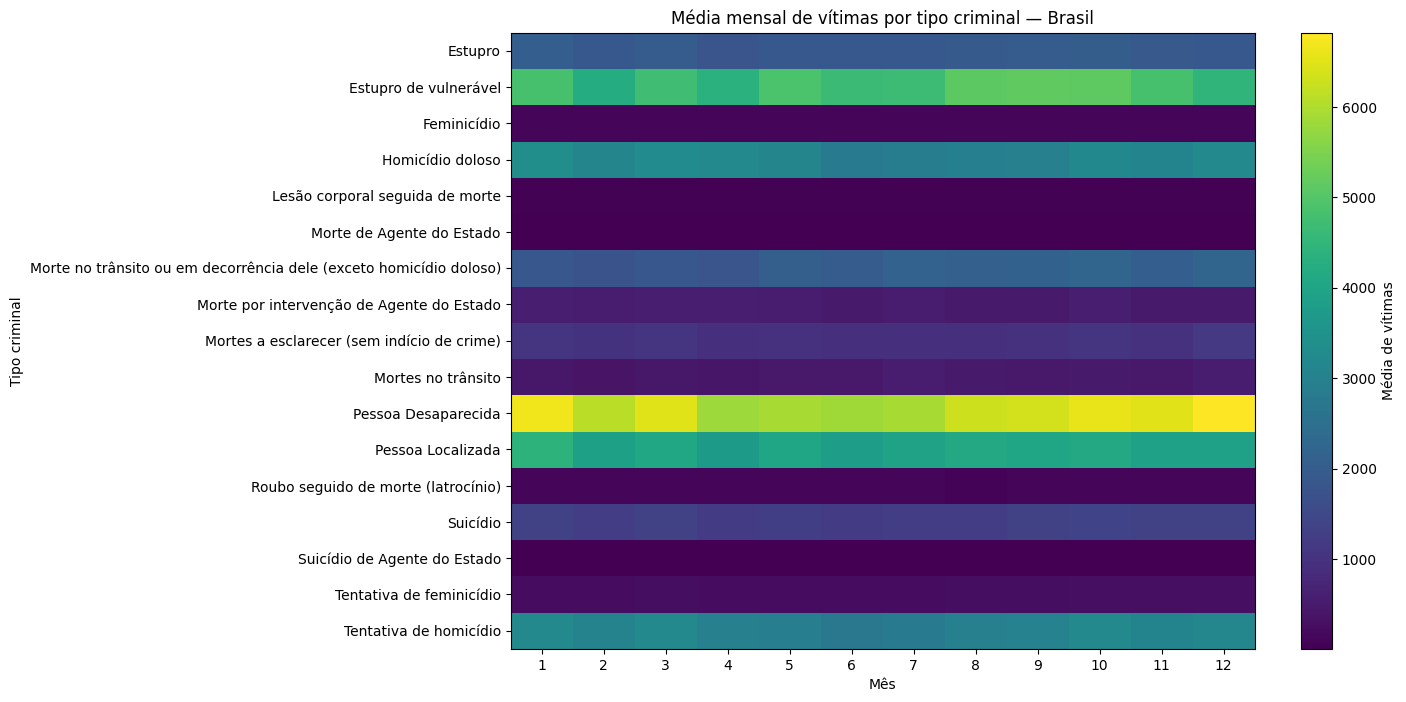

In [ ]:
matriz_evento_mes = (
    df_vitimas_BR
    .pivot_table(
        index="evento",
        columns="data_mes",
        values="total_vitima",
        aggfunc="mean"
    )
    .fillna(0)
)

plt.figure(figsize=(12, 8))
plt.imshow(matriz_evento_mes, aspect="auto")
plt.title("Média mensal de vítimas por tipo criminal — Brasil")
plt.xlabel("Mês")
plt.ylabel("Tipo criminal")
plt.xticks(range(12), matriz_evento_mes.columns)
plt.yticks(range(len(matriz_evento_mes.index)), matriz_evento_mes.index)
plt.colorbar(label="Média de vítimas")
plt.show()

## 4.13 Total de vítimas por UF

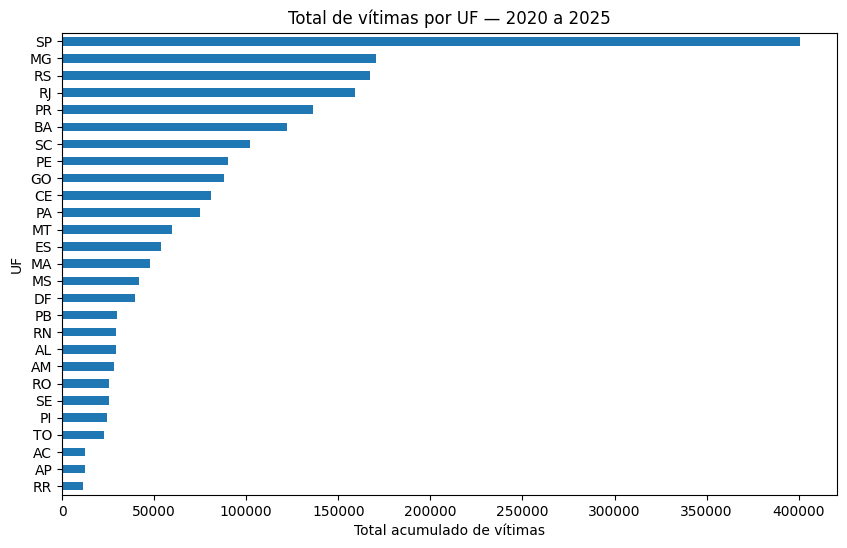

In [ ]:
vitimas_por_uf = (
    df_vitimas_UF
    .groupby("uf")["total_vitima"]
    .sum()
    .sort_values(ascending=False)
)

plotar_barras_ordenadas(
    vitimas_por_uf,
    "Total de vítimas por UF — 2020 a 2025",
    "Total acumulado de vítimas",
    "UF",
    top_n=None
)

## 4.14 Top 10 combinações UF × tipo criminal

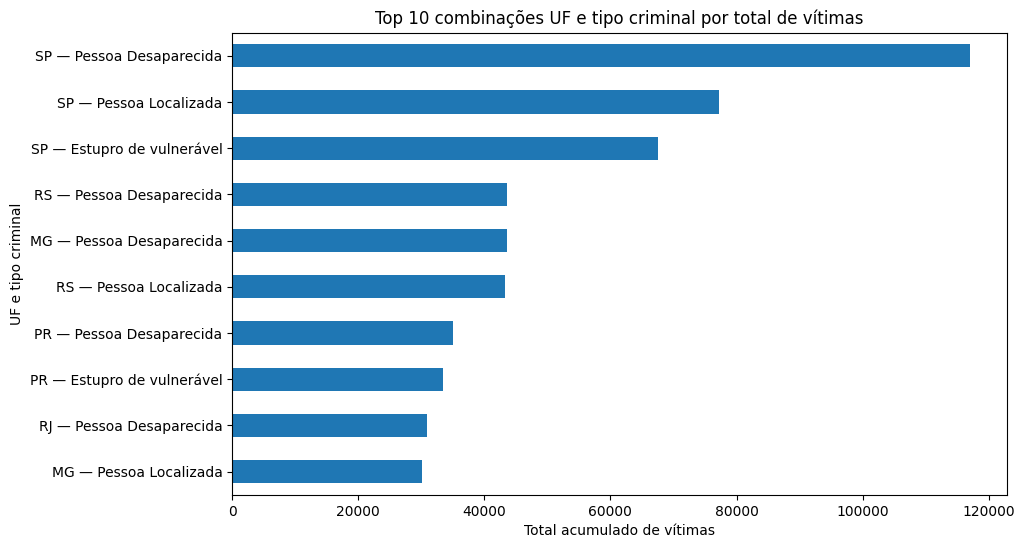

In [ ]:
top_uf_evento = (
    df_vitimas_UF
    .groupby(["uf", "evento"])["total_vitima"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_uf_evento.index = [f"{uf} — {evento}" for uf, evento in top_uf_evento.index]

plotar_barras_ordenadas(
    top_uf_evento,
    "Top 10 combinações UF e tipo criminal por total de vítimas",
    "Total acumulado de vítimas",
    "UF e tipo criminal",
    top_n=None
)

## 4.15 Evolução temporal por UF selecionada

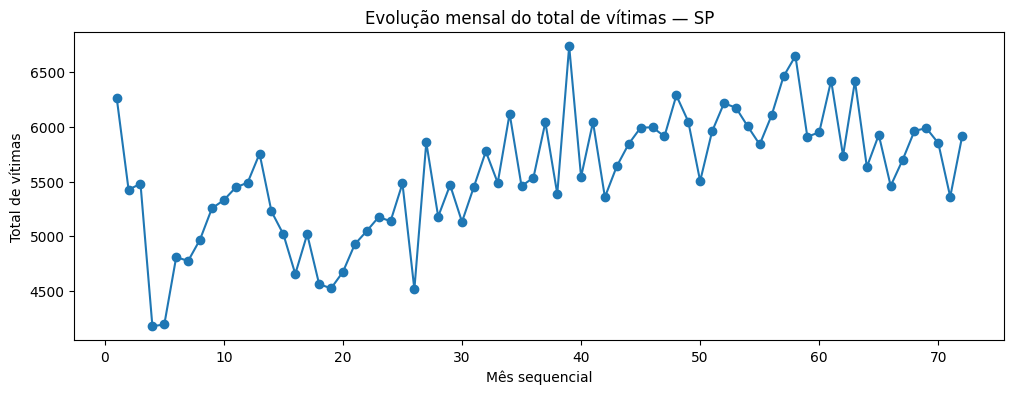

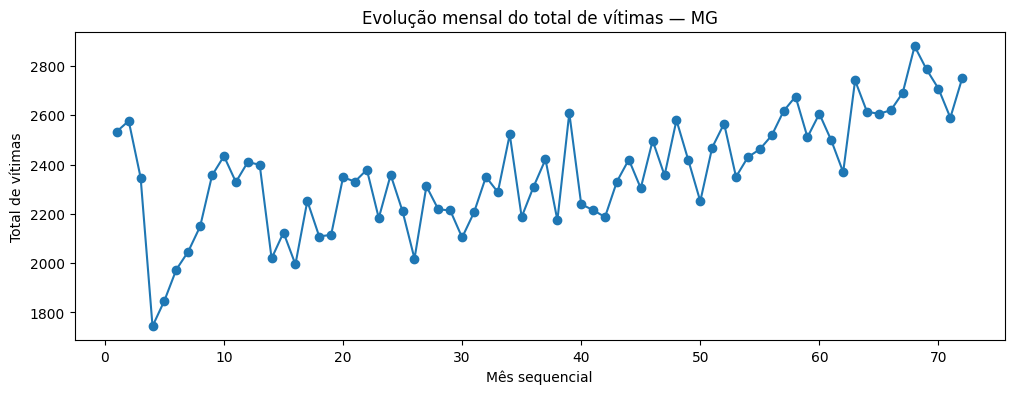

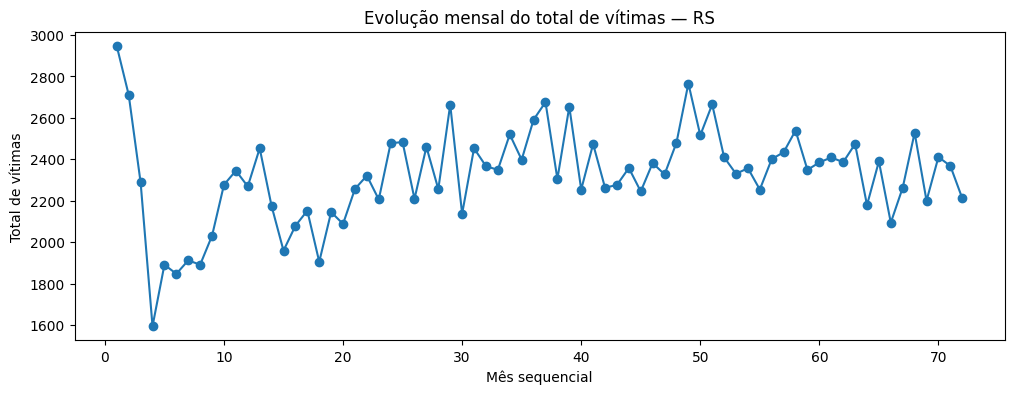

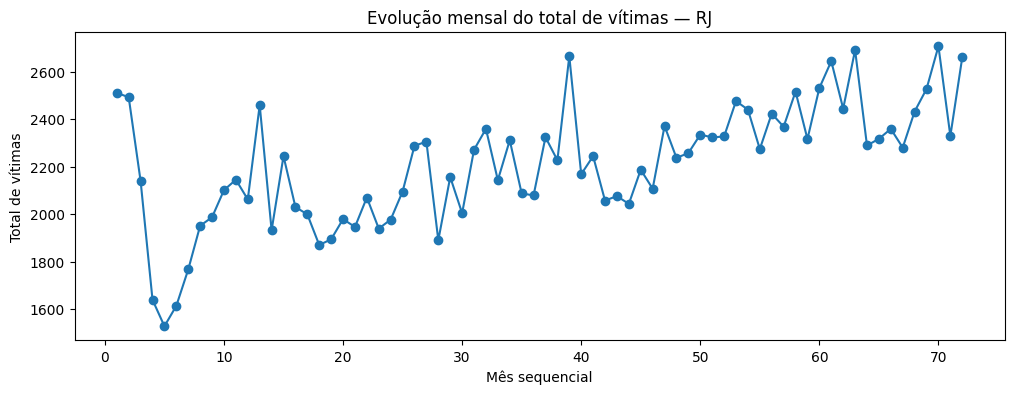

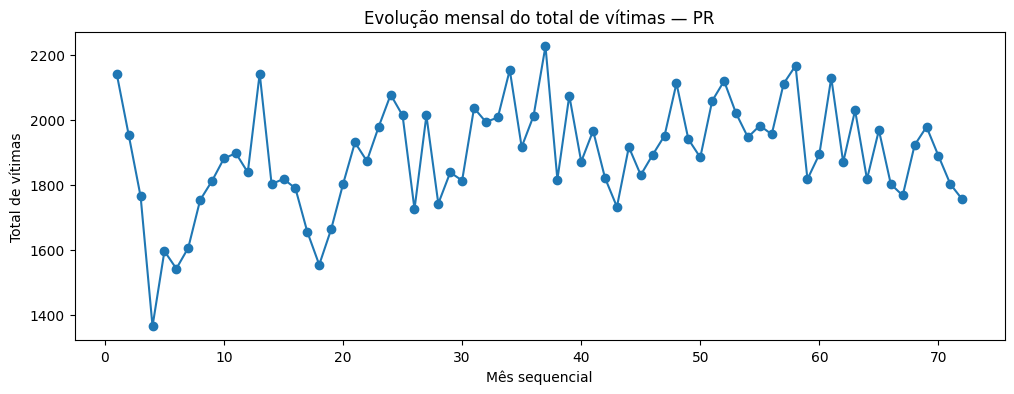

In [ ]:
ufs_maior_volume = vitimas_por_uf.head(5).index.tolist()

serie_uf_mensal = (
    df_vitimas_UF
    .groupby(["uf", "data_ano", "data_mes"], as_index=False)["total_vitima"]
    .sum()
)

serie_uf_mensal["indice_tempo_geral"] = (
    (serie_uf_mensal["data_ano"] - 2020) * 12
    + serie_uf_mensal["data_mes"]
)

for uf in ufs_maior_volume:
    dados_uf = serie_uf_mensal[serie_uf_mensal["uf"] == uf].sort_values("indice_tempo_geral")

    plt.figure(figsize=(12, 4))
    plt.plot(
        dados_uf["indice_tempo_geral"],
        dados_uf["total_vitima"],
        marker="o"
    )
    plt.title(f"Evolução mensal do total de vítimas — {uf}")
    plt.xlabel("Mês sequencial")
    plt.ylabel("Total de vítimas")
    plt.show()

## 4.16 Heatmap simples: total acumulado por UF e tipo criminal

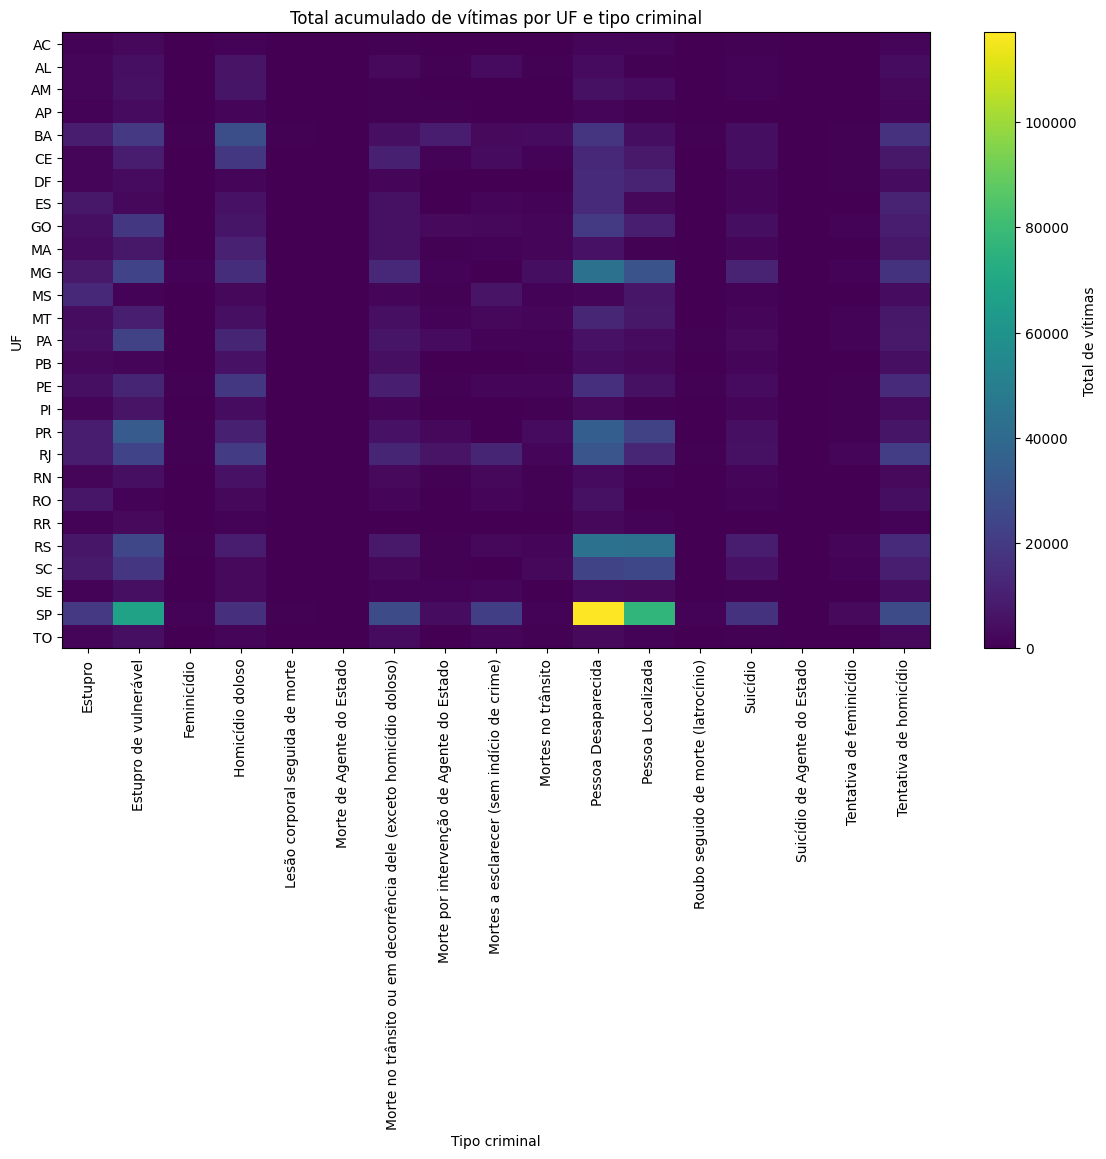

In [ ]:
matriz_uf_evento = (
    df_vitimas_UF
    .pivot_table(
        index="uf",
        columns="evento",
        values="total_vitima",
        aggfunc="sum"
    )
    .fillna(0)
)

plt.figure(figsize=(14, 8))
plt.imshow(matriz_uf_evento, aspect="auto")
plt.title("Total acumulado de vítimas por UF e tipo criminal")
plt.xlabel("Tipo criminal")
plt.ylabel("UF")
plt.xticks(range(len(matriz_uf_evento.columns)), matriz_uf_evento.columns, rotation=90)
plt.yticks(range(len(matriz_uf_evento.index)), matriz_uf_evento.index)
plt.colorbar(label="Total de vítimas")
plt.show()

## 4.17 Síntese da análise exploratória

A análise exploratória mostra que a base possui estrutura temporal mensal e forte diferença de magnitude entre tipos criminais e unidades federativas.

Em nível nacional, determinados eventos concentram maior volume de vítimas, enquanto outros possuem séries com valores menores. Em nível estadual, observa-se diferença importante entre UFs, reforçando a necessidade de incluir `uf` como atributo na modelagem estadual.

Os gráficos de evolução temporal indicam oscilações ao longo dos meses e anos, o que justifica o uso de atributos temporais como `data_mes`, `data_ano`, `num_evento_BR` e `num_evento_UF`.

# 5. Preparação dos dados e divisão treino/teste

A modelagem será feita separadamente para as duas bases:

1. `df_vitimas_BR`: previsão nacional.
2. `df_vitimas_UF`: previsão por UF.

## 5.1 Configuração da base nacional

In [ ]:
alvo_nacional = "total_vitima"
atributos_nacionais = ["evento", "data_mes", "data_ano", "num_evento_BR"]

base_modelagem_br = df_vitimas_BR.sort_values(
    ["data_ano", "data_mes", "evento"]
).copy()

# Treino: 2020 a 2024 | Teste: 2025
treino_br = base_modelagem_br[base_modelagem_br["data_ano"] <= 2024].copy()
teste_br = base_modelagem_br[base_modelagem_br["data_ano"] == 2025].copy()

X_treino_br = treino_br[atributos_nacionais].copy()
y_treino_br = treino_br[alvo_nacional].copy()

X_teste_br = teste_br[atributos_nacionais].copy()
y_teste_br = teste_br[alvo_nacional].copy()

print("Treino nacional:", X_treino_br.shape)
print("Teste nacional:", X_teste_br.shape)

Treino nacional: (1020, 4)
Teste nacional: (204, 4)


## 5.2 Configuração da base por UF

In [ ]:
alvo_estadual = "total_vitima"
atributos_estaduais = ["uf", "evento", "data_mes", "data_ano", "num_evento_UF"]

base_modelagem_uf = df_vitimas_UF.sort_values(
    ["data_ano", "data_mes", "uf", "evento"]
).copy()

# Treino: 2020 a 2024 | Teste: 2025
treino_uf = base_modelagem_uf[base_modelagem_uf["data_ano"] <= 2024].copy()
teste_uf = base_modelagem_uf[base_modelagem_uf["data_ano"] == 2025].copy()

X_treino_uf = treino_uf[atributos_estaduais].copy()
y_treino_uf = treino_uf[alvo_estadual].copy()

X_teste_uf = teste_uf[atributos_estaduais].copy()
y_teste_uf = teste_uf[alvo_estadual].copy()

print("Treino por UF:", X_treino_uf.shape)
print("Teste por UF:", X_teste_uf.shape)

Treino por UF: (23015, 5)
Teste por UF: (4689, 5)


## 5.3 Justificativa da divisão

A divisão entre treino e teste foi realizada de forma temporal. Os dados de 2020 a 2024 foram usados para treinamento, enquanto o ano de 2025 foi reservado para teste.

Essa estratégia evita vazamento de informação, pois impede que registros futuros sejam utilizados para treinar modelos que deveriam prever períodos posteriores. A avaliação em 2025 simula o cenário real de previsão para 2026.

# 6. Pré-processamento e pipeline

## 6.1 Transformações para a base nacional

In [ ]:
variaveis_numericas_br = ["data_mes", "data_ano", "num_evento_BR"]
variaveis_categoricas_br = ["evento"]

tratamento_numerico_br = Pipeline(
    steps=[
        ("preencher_mediana", SimpleImputer(strategy="median")),
        ("padronizar", StandardScaler())
    ]
)

tratamento_categorico_br = Pipeline(
    steps=[
        ("preencher_moda", SimpleImputer(strategy="most_frequent")),
        ("codificar", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preparacao_br = ColumnTransformer(
    transformers=[
        ("numericas", tratamento_numerico_br, variaveis_numericas_br),
        ("categoricas", tratamento_categorico_br, variaveis_categoricas_br)
    ],
    remainder="drop"
)

## 6.2 Transformações para a base por UF

In [ ]:
variaveis_numericas_uf = ["data_mes", "data_ano", "num_evento_UF"]
variaveis_categoricas_uf = ["uf", "evento"]

tratamento_numerico_uf = Pipeline(
    steps=[
        ("preencher_mediana", SimpleImputer(strategy="median")),
        ("padronizar", StandardScaler())
    ]
)

tratamento_categorico_uf = Pipeline(
    steps=[
        ("preencher_moda", SimpleImputer(strategy="most_frequent")),
        ("codificar", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preparacao_uf = ColumnTransformer(
    transformers=[
        ("numericas", tratamento_numerico_uf, variaveis_numericas_uf),
        ("categoricas", tratamento_categorico_uf, variaveis_categoricas_uf)
    ],
    remainder="drop"
)

## 6.3 Decisões de pré-processamento

As variáveis categóricas `evento` e `uf` foram codificadas por One-Hot Encoding. As variáveis numéricas foram padronizadas para permitir comparação adequada entre modelos lineares e modelos baseados em árvores.

Embora a base final não apresente valores ausentes relevantes, foram incluídas etapas de imputação para tornar o pipeline mais robusto e evitar falhas em futuras execuções.

Todas as variáveis utilizadas estariam disponíveis no momento real da previsão para 2026.

# 7. Baseline e modelos candidatos

## 7.1 Baseline nacional

O baseline nacional repete, para cada tipo criminal e mês de 2025, o valor observado no mesmo mês de 2024.

In [ ]:
referencia_br_2024 = (
    treino_br[treino_br["data_ano"] == 2024]
    [["evento", "data_mes", "total_vitima"]]
    .rename(columns={"total_vitima": "previsao_baseline"})
)

avaliacao_baseline_br = teste_br.merge(
    referencia_br_2024,
    on=["evento", "data_mes"],
    how="left"
)

resultado_baseline_br = medir_desempenho_regressao(
    avaliacao_baseline_br["total_vitima"],
    avaliacao_baseline_br["previsao_baseline"]
)

resultado_baseline_br

{'MAE': 123.73039215686275,
 'RMSE': np.float64(202.0547028435034),
 'R2': 0.9904634150020242}

## 7.2 Baseline por UF

O baseline estadual repete, para cada UF, tipo criminal e mês de 2025, o valor observado no mesmo mês de 2024.

Para o baseline por UF, algumas combinações existentes em 2025 não possuíam correspondente no mesmo mês de 2024. Nesses casos, a previsão ausente foi preenchida com a mediana histórica da respectiva combinação UF + evento. Quando ainda assim não havia referência, foi utilizada a mediana geral do conjunto de treino.

In [ ]:
# Baseline por UF: usa o valor do mesmo mês do ano anterior.
# Quando não houver referência em 2024, usa a mediana histórica daquele UF + evento.

referencia_uf_2024 = (
    treino_uf[treino_uf["data_ano"] == 2024]
    [["uf", "evento", "data_mes", "total_vitima"]]
    .rename(columns={"total_vitima": "previsao_baseline"})
)

avaliacao_baseline_uf = teste_uf.merge(
    referencia_uf_2024,
    on=["uf", "evento", "data_mes"],
    how="left"
)

# Mediana histórica por UF e evento, usada para preencher ausências no baseline
mediana_uf_evento = (
    treino_uf
    .groupby(["uf", "evento"])["total_vitima"]
    .median()
    .reset_index()
    .rename(columns={"total_vitima": "mediana_historica"})
)

avaliacao_baseline_uf = avaliacao_baseline_uf.merge(
    mediana_uf_evento,
    on=["uf", "evento"],
    how="left"
)

# Preenche previsões ausentes com a mediana histórica do respectivo UF + evento
avaliacao_baseline_uf["previsao_baseline"] = (
    avaliacao_baseline_uf["previsao_baseline"]
    .fillna(avaliacao_baseline_uf["mediana_historica"])
)

# Segurança extra: se ainda houver NaN, usa a mediana geral do treino
avaliacao_baseline_uf["previsao_baseline"] = (
    avaliacao_baseline_uf["previsao_baseline"]
    .fillna(treino_uf["total_vitima"].median())
)

resultado_baseline_uf = medir_desempenho_regressao(
    avaliacao_baseline_uf["total_vitima"],
    avaliacao_baseline_uf["previsao_baseline"]
)

resultado_baseline_uf

{'MAE': 14.6744508423971,
 'RMSE': np.float64(30.660710602725885),
 'R2': 0.9616667579220591}

## 7.3 Modelos candidatos nacionais

In [ ]:
modelos_br = {
    "Regressao_Linear_BR": Pipeline(
        steps=[("preparacao", preparacao_br), ("estimador", LinearRegression())]
    ),
    "Ridge_BR": Pipeline(
        steps=[("preparacao", preparacao_br), ("estimador", Ridge())]
    ),
    "Floresta_Aleatoria_BR": Pipeline(
        steps=[
            ("preparacao", preparacao_br),
            ("estimador", RandomForestRegressor(n_estimators=200, random_state=SEMENTE))
        ]
    ),
    "Gradiente_BR": Pipeline(
        steps=[
            ("preparacao", preparacao_br),
            ("estimador", GradientBoostingRegressor(random_state=SEMENTE))
        ]
    )
}

print(list(modelos_br.keys()))

['Regressao_Linear_BR', 'Ridge_BR', 'Floresta_Aleatoria_BR', 'Gradiente_BR']


## 7.4 Modelos candidatos por UF

In [ ]:
modelos_uf = {
    "Regressao_Linear_UF": Pipeline(
        steps=[("preparacao", preparacao_uf), ("estimador", LinearRegression())]
    ),
    "Ridge_UF": Pipeline(
        steps=[("preparacao", preparacao_uf), ("estimador", Ridge())]
    ),
    "Floresta_Aleatoria_UF": Pipeline(
        steps=[
            ("preparacao", preparacao_uf),
            ("estimador", RandomForestRegressor(n_estimators=200, random_state=SEMENTE, n_jobs=-1))
        ]
    ),
    "Gradiente_UF": Pipeline(
        steps=[
            ("preparacao", preparacao_uf),
            ("estimador", GradientBoostingRegressor(random_state=SEMENTE))
        ]
    )
}

print(list(modelos_uf.keys()))

['Regressao_Linear_UF', 'Ridge_UF', 'Floresta_Aleatoria_UF', 'Gradiente_UF']


## 7.5 Justificativa dos modelos

Foram selecionados modelos lineares e modelos baseados em árvores para comparar abordagens de diferentes complexidades.

A Regressão Linear e o Ridge funcionam como modelos supervisionados simples e interpretáveis. A Floresta Aleatória e o Gradiente são capazes de capturar relações não lineares e interações entre variáveis.

A comparação com os baselines permite verificar se os modelos de Machine Learning realmente acrescentam capacidade preditiva em relação a uma regra temporal simples.

# 8. Treinamento e avaliação inicial

## 8.1 Treinamento e avaliação — Brasil

In [ ]:
desempenho_br = {"Baseline_BR": resultado_baseline_br}
modelos_treinados_br = {}
previsoes_teste_br = {}

for nome_modelo, modelo in modelos_br.items():
    inicio = time.time()

    modelo.fit(X_treino_br, y_treino_br)
    duracao = time.time() - inicio

    previsao = modelo.predict(X_teste_br)

    desempenho_br[nome_modelo] = medir_desempenho_regressao(y_teste_br, previsao)
    desempenho_br[nome_modelo]["tempo_treino_seg"] = round(duracao, 3)

    modelos_treinados_br[nome_modelo] = modelo
    previsoes_teste_br[nome_modelo] = previsao

tabela_br_inicial = montar_quadro_comparativo(desempenho_br)
display(tabela_br_inicial)

,MAE,RMSE,R2,tempo_treino_seg
Baseline_BR,123.730392,202.054703,0.990463,NaN
Floresta_Aleatoria_BR,127.112525,204.791373,0.990203,1.299
Gradiente_BR,207.445387,274.503477,0.982398,0.124
Regressao_Linear_BR,357.672740,443.980973,0.953955,0.040
Ridge_BR,375.416830,459.281084,0.950727,0.010


## 8.2 Treinamento e avaliação — UF

In [ ]:
desempenho_uf = {"Baseline_UF": resultado_baseline_uf}
modelos_treinados_uf = {}
previsoes_teste_uf = {}

for nome_modelo, modelo in modelos_uf.items():
    inicio = time.time()

    modelo.fit(X_treino_uf, y_treino_uf)
    duracao = time.time() - inicio

    previsao = modelo.predict(X_teste_uf)

    desempenho_uf[nome_modelo] = medir_desempenho_regressao(y_teste_uf, previsao)
    desempenho_uf[nome_modelo]["tempo_treino_seg"] = round(duracao, 3)

    modelos_treinados_uf[nome_modelo] = modelo
    previsoes_teste_uf[nome_modelo] = previsao

tabela_uf_inicial = montar_quadro_comparativo(desempenho_uf)
display(tabela_uf_inicial)

,MAE,RMSE,R2,tempo_treino_seg
Floresta_Aleatoria_UF,12.838536,26.864013,0.970573,126.151
Baseline_UF,14.674451,30.660711,0.961667,NaN
Gradiente_UF,38.616818,62.741227,0.839484,0.834
Ridge_UF,59.457098,113.380000,0.475816,0.055
Regressao_Linear_UF,59.492016,113.383280,0.475785,0.096


## 8.3 Visualização dos erros iniciais — Brasil

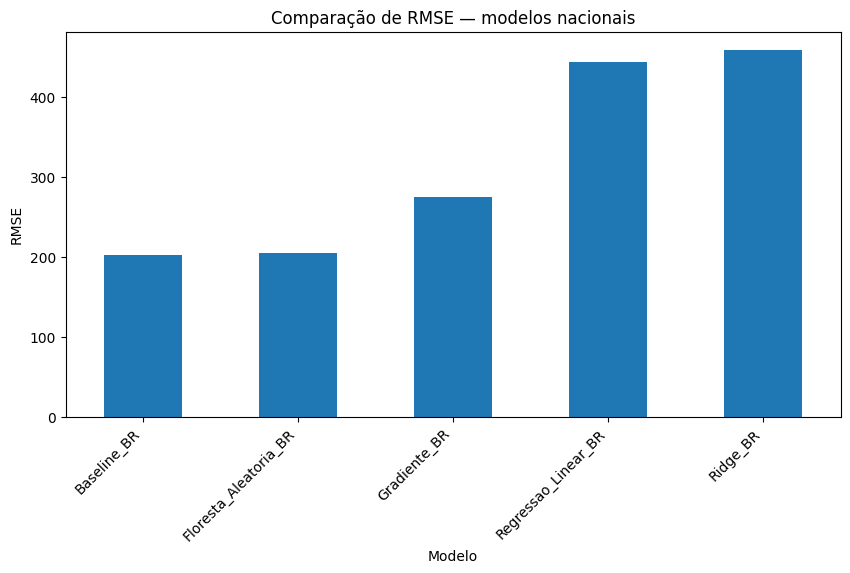

In [ ]:
plt.figure(figsize=(10, 5))
tabela_br_inicial["RMSE"].sort_values().plot(kind="bar")
plt.title("Comparação de RMSE — modelos nacionais")
plt.xlabel("Modelo")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.show()

## 8.4 Visualização dos erros iniciais — UF

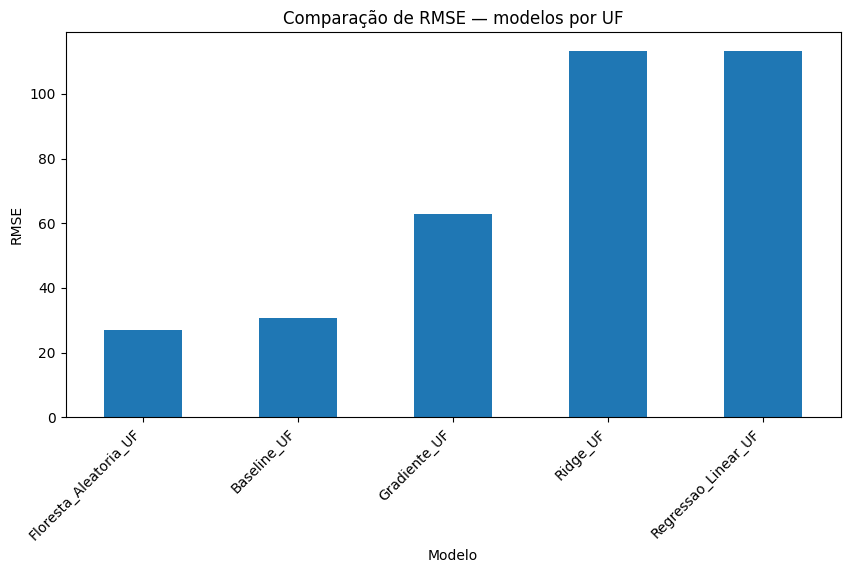

In [ ]:
plt.figure(figsize=(10, 5))
tabela_uf_inicial["RMSE"].sort_values().plot(kind="bar")
plt.title("Comparação de RMSE — modelos por UF")
plt.xlabel("Modelo")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.show()

# 9. Otimização de hiperparâmetros

A otimização será aplicada à Floresta Aleatória, pois é um modelo robusto para dados tabulares e permite ajuste de hiperparâmetros relevantes.

## 9.1 Otimização nacional

In [ ]:
floresta_base_br = Pipeline(
    steps=[
        ("preparacao", preparacao_br),
        ("estimador", RandomForestRegressor(random_state=SEMENTE, n_jobs=-1))
    ]
)

grade_br = {
    "estimador__n_estimators": [100, 200],
    "estimador__max_depth": [8, None],
    "estimador__min_samples_leaf": [1, 2]
}

validacao_br = TimeSeriesSplit(n_splits=3)

busca_br = GridSearchCV(
    estimator=floresta_base_br,
    param_grid=grade_br,
    scoring="neg_root_mean_squared_error",
    cv=validacao_br,
    n_jobs=-1
)

busca_br.fit(X_treino_br, y_treino_br)

print("Melhores parâmetros nacionais:")
print(busca_br.best_params_)

Melhores parâmetros nacionais:
{'estimador__max_depth': None, 'estimador__min_samples_leaf': 1, 'estimador__n_estimators': 200}


## 9.2 Otimização por UF

In [ ]:
floresta_base_uf = Pipeline(
    steps=[
        ("preparacao", preparacao_uf),
        ("estimador", RandomForestRegressor(random_state=SEMENTE, n_jobs=-1))
    ]
)

grade_uf = {
    "estimador__n_estimators": [100, 200],
    "estimador__max_depth": [10, None],
    "estimador__min_samples_leaf": [1, 2]
}

validacao_uf = TimeSeriesSplit(n_splits=3)

busca_uf = GridSearchCV(
    estimator=floresta_base_uf,
    param_grid=grade_uf,
    scoring="neg_root_mean_squared_error",
    cv=validacao_uf,
    n_jobs=-1
)

busca_uf.fit(X_treino_uf, y_treino_uf)

print("Melhores parâmetros por UF:")
print(busca_uf.best_params_)

## 9.3 Avaliação dos modelos ajustados

In [ ]:
# Avaliação nacional ajustada
modelo_br_ajustado = busca_br.best_estimator_
previsao_br_ajustada = modelo_br_ajustado.predict(X_teste_br)

desempenho_br["Floresta_Ajustada_BR"] = medir_desempenho_regressao(
    y_teste_br,
    previsao_br_ajustada
)

# Avaliação estadual ajustada
modelo_uf_ajustado = busca_uf.best_estimator_
previsao_uf_ajustada = modelo_uf_ajustado.predict(X_teste_uf)

desempenho_uf["Floresta_Ajustada_UF"] = medir_desempenho_regressao(
    y_teste_uf,
    previsao_uf_ajustada
)

tabela_br_final = montar_quadro_comparativo(desempenho_br)
tabela_uf_final = montar_quadro_comparativo(desempenho_uf)

print("Resultado final — Brasil")
display(tabela_br_final)

print("Resultado final — UF")
display(tabela_uf_final)

# 10. Avaliação final e comprovação das hipóteses

## 10.1 Comparação final com baseline

In [ ]:
# Nacional
rmse_baseline_br = tabela_br_final.loc["Baseline_BR", "RMSE"]
melhor_modelo_br = tabela_br_final.index[0]
rmse_melhor_br = tabela_br_final.iloc[0]["RMSE"]
reducao_br = calcular_reducao_percentual(rmse_baseline_br, rmse_melhor_br)

# UF
rmse_baseline_uf = tabela_uf_final.loc["Baseline_UF", "RMSE"]
melhor_modelo_uf = tabela_uf_final.index[0]
rmse_melhor_uf = tabela_uf_final.iloc[0]["RMSE"]
reducao_uf = calcular_reducao_percentual(rmse_baseline_uf, rmse_melhor_uf)

print("Melhor modelo nacional:", melhor_modelo_br)
print(f"Redução de RMSE nacional frente ao baseline: {reducao_br:.2f}%")

print("
Melhor modelo por UF:", melhor_modelo_uf)
print(f"Redução de RMSE por UF frente ao baseline: {reducao_uf:.2f}%")

## 10.2 Hipótese 1 — existência de padrões temporais úteis

A Hipótese 1 será considerada apoiada se o melhor modelo apresentar desempenho melhor que o baseline ou R² positivo no conjunto de teste. Isso indicaria que os dados históricos possuem algum padrão aproveitável para previsão.

In [ ]:
h1_br = (rmse_melhor_br < rmse_baseline_br) or (tabela_br_final.iloc[0]["R2"] > 0)
h1_uf = (rmse_melhor_uf < rmse_baseline_uf) or (tabela_uf_final.iloc[0]["R2"] > 0)

print("Hipótese 1 — Brasil:", "Apoiada" if h1_br else "Não apoiada")
print("Hipótese 1 — UF:", "Apoiada" if h1_uf else "Não apoiada")

## 10.3 Hipótese 2 — contribuição da variável mês

Para verificar se `data_mes` contribui para a modelagem, será comparado o desempenho de uma Floresta Aleatória com todos os atributos contra outra sem a variável `data_mes`.

In [ ]:
# Modelo nacional sem data_mes
atributos_br_sem_mes = ["evento", "data_ano", "num_evento_BR"]
preparacao_br_sem_mes = ColumnTransformer(
    transformers=[
        ("numericas", tratamento_numerico_br, ["data_ano", "num_evento_BR"]),
        ("categoricas", tratamento_categorico_br, ["evento"])
    ],
    remainder="drop"
)

modelo_br_sem_mes = Pipeline(
    steps=[
        ("preparacao", preparacao_br_sem_mes),
        ("estimador", RandomForestRegressor(n_estimators=200, random_state=SEMENTE, n_jobs=-1))
    ]
)

modelo_br_sem_mes.fit(treino_br[atributos_br_sem_mes], y_treino_br)
previsao_br_sem_mes = modelo_br_sem_mes.predict(teste_br[atributos_br_sem_mes])
resultado_br_sem_mes = medir_desempenho_regressao(y_teste_br, previsao_br_sem_mes)

# Modelo por UF sem data_mes
atributos_uf_sem_mes = ["uf", "evento", "data_ano", "num_evento_UF"]
preparacao_uf_sem_mes = ColumnTransformer(
    transformers=[
        ("numericas", tratamento_numerico_uf, ["data_ano", "num_evento_UF"]),
        ("categoricas", tratamento_categorico_uf, ["uf", "evento"])
    ],
    remainder="drop"
)

modelo_uf_sem_mes = Pipeline(
    steps=[
        ("preparacao", preparacao_uf_sem_mes),
        ("estimador", RandomForestRegressor(n_estimators=200, random_state=SEMENTE, n_jobs=-1))
    ]
)

modelo_uf_sem_mes.fit(treino_uf[atributos_uf_sem_mes], y_treino_uf)
previsao_uf_sem_mes = modelo_uf_sem_mes.predict(teste_uf[atributos_uf_sem_mes])
resultado_uf_sem_mes = medir_desempenho_regressao(y_teste_uf, previsao_uf_sem_mes)

comparacao_mes = pd.DataFrame({
    "Brasil_com_mes": tabela_br_final.loc[melhor_modelo_br],
    "Brasil_sem_mes": resultado_br_sem_mes,
    "UF_com_mes": tabela_uf_final.loc[melhor_modelo_uf],
    "UF_sem_mes": resultado_uf_sem_mes
}).T

display(comparacao_mes[["MAE", "RMSE", "R2"]])

h2_br = tabela_br_final.loc[melhor_modelo_br, "RMSE"] < resultado_br_sem_mes["RMSE"]
h2_uf = tabela_uf_final.loc[melhor_modelo_uf, "RMSE"] < resultado_uf_sem_mes["RMSE"]

print("Hipótese 2 — Brasil:", "Apoiada" if h2_br else "Não apoiada")
print("Hipótese 2 — UF:", "Apoiada" if h2_uf else "Não apoiada")

## 10.4 Hipótese 3 — superação do baseline em pelo menos 10%

A Hipótese 3 será considerada confirmada se o melhor modelo reduzir o RMSE em pelo menos 10% em relação ao baseline.

In [ ]:
h3_br = reducao_br >= 10
h3_uf = reducao_uf >= 10

print("Hipótese 3 — Brasil:", "Confirmada" if h3_br else "Não confirmada")
print(f"Redução obtida no Brasil: {reducao_br:.2f}%")

print("
Hipótese 3 — UF:", "Confirmada" if h3_uf else "Não confirmada")
print(f"Redução obtida por UF: {reducao_uf:.2f}%")

## 10.5 Quadro-resumo das hipóteses

In [ ]:
resumo_hipoteses = pd.DataFrame({
    "Hipótese": [
        "H1: padrões temporais úteis",
        "H2: contribuição da variável mês",
        "H3: redução de RMSE >= 10% frente ao baseline"
    ],
    "Brasil": [
        "Apoiada" if h1_br else "Não apoiada",
        "Apoiada" if h2_br else "Não apoiada",
        "Confirmada" if h3_br else "Não confirmada"
    ],
    "UF": [
        "Apoiada" if h1_uf else "Não apoiada",
        "Apoiada" if h2_uf else "Não apoiada",
        "Confirmada" if h3_uf else "Não confirmada"
    ]
})

display(resumo_hipoteses)

## 10.6 Gráficos de valores reais versus previstos — Brasil

In [ ]:
# Seleciona a previsão do melhor modelo nacional.
if melhor_modelo_br == "Floresta_Ajustada_BR":
    melhor_previsao_br = previsao_br_ajustada
elif melhor_modelo_br in previsoes_teste_br:
    melhor_previsao_br = previsoes_teste_br[melhor_modelo_br]
else:
    melhor_previsao_br = avaliacao_baseline_br["previsao_baseline"].values

comparacao_real_previsto_br = teste_br.copy()
comparacao_real_previsto_br["previsto"] = melhor_previsao_br
comparacao_real_previsto_br["erro_absoluto"] = abs(
    comparacao_real_previsto_br["total_vitima"] - comparacao_real_previsto_br["previsto"]
)

plt.figure(figsize=(6, 6))
plt.scatter(
    comparacao_real_previsto_br["total_vitima"],
    comparacao_real_previsto_br["previsto"]
)
plt.title("Valores reais versus previstos — Brasil")
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.show()

## 10.7 Gráficos de valores reais versus previstos — UF

In [ ]:
# Seleciona a previsão do melhor modelo estadual.
if melhor_modelo_uf == "Floresta_Ajustada_UF":
    melhor_previsao_uf = previsao_uf_ajustada
elif melhor_modelo_uf in previsoes_teste_uf:
    melhor_previsao_uf = previsoes_teste_uf[melhor_modelo_uf]
else:
    melhor_previsao_uf = avaliacao_baseline_uf["previsao_baseline"].values

comparacao_real_previsto_uf = teste_uf.copy()
comparacao_real_previsto_uf["previsto"] = melhor_previsao_uf
comparacao_real_previsto_uf["erro_absoluto"] = abs(
    comparacao_real_previsto_uf["total_vitima"] - comparacao_real_previsto_uf["previsto"]
)

plt.figure(figsize=(6, 6))
plt.scatter(
    comparacao_real_previsto_uf["total_vitima"],
    comparacao_real_previsto_uf["previsto"]
)
plt.title("Valores reais versus previstos — UF")
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.show()

## 10.8 Erro médio absoluto por tipo criminal — Brasil

In [ ]:
erro_evento_br = (
    comparacao_real_previsto_br
    .groupby("evento")["erro_absoluto"]
    .mean()
    .sort_values(ascending=False)
)

plotar_barras_ordenadas(
    erro_evento_br,
    "Erro absoluto médio por tipo criminal — Brasil",
    "Erro absoluto médio",
    "Tipo criminal",
    top_n=10
)

## 10.9 Erro médio absoluto por UF

In [ ]:
erro_uf = (
    comparacao_real_previsto_uf
    .groupby("uf")["erro_absoluto"]
    .mean()
    .sort_values(ascending=False)
)

plotar_barras_ordenadas(
    erro_uf,
    "Erro absoluto médio por UF",
    "Erro absoluto médio",
    "UF",
    top_n=None
)

# 11. Previsão para 2026

As previsões finais serão geradas para 2026 em dois níveis:

1. Nacional: tipo criminal × mês.
2. Estadual: UF × tipo criminal × mês.

## 11.1 Treinamento final — Brasil

In [ ]:
# Usa o modelo ajustado nacional para treinar com todo o histórico disponível.
modelo_final_br = busca_br.best_estimator_

X_historico_br = base_modelagem_br[atributos_nacionais].copy()
y_historico_br = base_modelagem_br[alvo_nacional].copy()

modelo_final_br.fit(X_historico_br, y_historico_br)

## 11.2 Treinamento final — UF

In [ ]:
# Usa o modelo ajustado por UF para treinar com todo o histórico disponível.
modelo_final_uf = busca_uf.best_estimator_

X_historico_uf = base_modelagem_uf[atributos_estaduais].copy()
y_historico_uf = base_modelagem_uf[alvo_estadual].copy()

modelo_final_uf.fit(X_historico_uf, y_historico_uf)

## 11.3 Base futura nacional — 2026

In [ ]:
tipos_criminais_br = sorted(base_modelagem_br["evento"].unique())

df_previsao_BR_2026 = pd.DataFrame(
    [
        {
            "evento": tipo,
            "data_mes": mes,
            "data_ano": 2026,
            "num_evento_BR": ((2026 - 2020) * 12) + mes
        }
        for tipo in tipos_criminais_br
        for mes in range(1, 13)
    ]
)

df_previsao_BR_2026["previsao_total_vitima"] = modelo_final_br.predict(
    df_previsao_BR_2026
)

df_previsao_BR_2026["previsao_total_vitima"] = (
    df_previsao_BR_2026["previsao_total_vitima"]
    .clip(lower=0)
    .round(0)
)

display(df_previsao_BR_2026.head(20))

## 11.4 Base futura por UF — 2026

In [ ]:
ufs = sorted(base_modelagem_uf["uf"].unique())
tipos_criminais_uf = sorted(base_modelagem_uf["evento"].unique())

df_previsao_UF_2026 = pd.DataFrame(
    [
        {
            "uf": uf,
            "evento": tipo,
            "data_mes": mes,
            "data_ano": 2026,
            "num_evento_UF": ((2026 - 2020) * 12) + mes
        }
        for uf in ufs
        for tipo in tipos_criminais_uf
        for mes in range(1, 13)
    ]
)

df_previsao_UF_2026["previsao_total_vitima"] = modelo_final_uf.predict(
    df_previsao_UF_2026
)

df_previsao_UF_2026["previsao_total_vitima"] = (
    df_previsao_UF_2026["previsao_total_vitima"]
    .clip(lower=0)
    .round(0)
)

display(df_previsao_UF_2026.head(20))

## 11.5 Gráfico de previsão nacional para tipos criminais selecionados

In [ ]:
for tipo in top5_eventos:
    dados_prev_tipo = df_previsao_BR_2026[
        df_previsao_BR_2026["evento"] == tipo
    ]

    plt.figure(figsize=(10, 4))
    plt.plot(
        dados_prev_tipo["data_mes"],
        dados_prev_tipo["previsao_total_vitima"],
        marker="o"
    )
    plt.title(f"Previsão nacional mensal para 2026 — {tipo}")
    plt.xlabel("Mês")
    plt.ylabel("Previsão de vítimas")
    plt.xticks(range(1, 13))
    plt.show()

## 11.6 Total previsto por tipo criminal — Brasil, 2026

In [ ]:
previsao_total_evento_2026 = (
    df_previsao_BR_2026
    .groupby("evento")["previsao_total_vitima"]
    .sum()
    .sort_values(ascending=False)
)

plotar_barras_ordenadas(
    previsao_total_evento_2026,
    "Total previsto por tipo criminal — Brasil, 2026",
    "Total previsto de vítimas",
    "Tipo criminal",
    top_n=10
)

## 11.7 Total previsto por UF — 2026

In [ ]:
previsao_total_uf_2026 = (
    df_previsao_UF_2026
    .groupby("uf")["previsao_total_vitima"]
    .sum()
    .sort_values(ascending=False)
)

plotar_barras_ordenadas(
    previsao_total_uf_2026,
    "Total previsto por UF — 2026",
    "Total previsto de vítimas",
    "UF",
    top_n=None
)

## 11.8 Heatmap simples: previsão por UF e tipo criminal — 2026

In [ ]:
matriz_previsao_uf_evento = (
    df_previsao_UF_2026
    .pivot_table(
        index="uf",
        columns="evento",
        values="previsao_total_vitima",
        aggfunc="sum"
    )
    .fillna(0)
)

plt.figure(figsize=(14, 8))
plt.imshow(matriz_previsao_uf_evento, aspect="auto")
plt.title("Previsão total de vítimas por UF e tipo criminal — 2026")
plt.xlabel("Tipo criminal")
plt.ylabel("UF")
plt.xticks(range(len(matriz_previsao_uf_evento.columns)), matriz_previsao_uf_evento.columns, rotation=90)
plt.yticks(range(len(matriz_previsao_uf_evento.index)), matriz_previsao_uf_evento.index)
plt.colorbar(label="Previsão total de vítimas")
plt.show()

## 11.9 Exportação das previsões

In [ ]:
df_previsao_BR_2026.to_csv(
    "previsao_nacional_vitimas_2026.csv",
    index=False,
    encoding="utf-8-sig"
)

df_previsao_UF_2026.to_csv(
    "previsao_uf_vitimas_2026.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivos de previsão exportados com sucesso.")

# 12. Conclusão

Este MVP desenvolveu modelos de regressão para prever a quantidade mensal de vítimas por tipo criminal em 2026, utilizando dados oficiais do SINESP referentes ao período de 2020 a 2025.

A modelagem foi realizada em dois níveis:

- **Nacional:** previsão por tipo criminal para o Brasil.
- **Estadual:** previsão por tipo criminal e por UF.

Foram avaliados baselines temporais, modelos lineares e modelos baseados em árvores. A avaliação utilizou o ano de 2025 como conjunto de teste, preservando a ordem temporal dos dados.

A comprovação das hipóteses foi feita de forma objetiva, comparando RMSE, R² e o impacto da variável `data_mes`. O critério principal de sucesso foi a redução de pelo menos 10% do RMSE em relação ao baseline.

## Limitações

As principais limitações deste MVP são:

- uso de poucos atributos explicativos;
- ausência de variáveis socioeconômicas, demográficas e populacionais;
- ausência de taxa por 100 mil habitantes;
- possibilidade de subnotificação ou diferenças metodológicas entre unidades federativas;
- uso de modelos supervisionados tabulares para um problema com características temporais.

## Trabalhos futuros

Como próximos passos, recomenda-se:

- calcular taxas por 100 mil habitantes;
- incluir população por UF e ano;
- criar variáveis defasadas, como valor do mês anterior e média móvel;
- avaliar modelos específicos de séries temporais;
- comparar previsões por região do país;
- aprofundar a análise dos erros por tipo criminal e por UF.

# 13. Checklist final

- [x] Definição do problema  
- [x] Descrição da fonte dos dados  
- [x] Carga direta no notebook  
- [x] Construção da base nacional  
- [x] Construção da base por UF  
- [x] Análise exploratória com múltiplos gráficos  
- [x] Divisão temporal treino/teste  
- [x] Baseline nacional  
- [x] Baseline por UF  
- [x] Modelos candidatos nacionais  
- [x] Modelos candidatos por UF  
- [x] Otimização de hiperparâmetros  
- [x] Avaliação final  
- [x] Comprovação das hipóteses  
- [x] Previsão nacional para 2026  
- [x] Previsão por UF para 2026  
- [x] Discussão de limitações  
- [x] Conclusão